# Spatial Interpolation

## Overview

Spatial interpolation predicts values at unsampled locations using values at known sample points. It transforms point observations into continuous surfaces.

**Methods compared:**

| Method | Type | Strength | Weakness |
|---|---|---|---|
| IDW | Deterministic | Simple, fast | No uncertainty, exact interpolator |
| Kriging (ordinary) | Geostatistical | Provides uncertainty estimates | Requires variogram fitting |
| Thin-plate spline | Deterministic | Smooth surface | No uncertainty |
| Nearest neighbour | Deterministic | Preserves data values | Discontinuous surface |
| Regression kriging | Hybrid | Uses covariates | Complex setup |

**Kriging advantage:** it is the best linear unbiased predictor (BLUP) under the assumed covariance model, and uniquely provides prediction variance alongside the interpolated value.

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from scipy.optimize import curve_fit
from scipy.interpolate import RBFInterpolator, NearestNDInterpolator
import warnings; warnings.filterwarnings('ignore')

rng = np.random.default_rng(42)

# Known sample points (monitoring sites)
n_obs = 50
x_obs = rng.uniform(0, 10000, n_obs)
y_obs = rng.uniform(0, 10000, n_obs)
# True underlying field (unknown): smooth + spatial correlation
true_field = lambda x, y: (20 - 0.001*y + 0.5*np.sin(x/2000)
                            + 0.3*np.cos(y/1500))
z_obs = true_field(x_obs, y_obs) + rng.normal(0, 0.5, n_obs)   # add measurement noise
# Prediction grid
grid_n = 80
gx = np.linspace(0, 10000, grid_n)
gy = np.linspace(0, 10000, grid_n)
GX, GY = np.meshgrid(gx, gy)
z_true = true_field(GX, GY)
print(f"Sample points: {n_obs}, prediction grid: {grid_n}×{grid_n}")
print(f"Observed range: {z_obs.min():.2f}–{z_obs.max():.2f}")

Sample points: 50, prediction grid: 80×80
Observed range: 10.71–20.74


---
## IDW and Nearest-Neighbour Interpolation

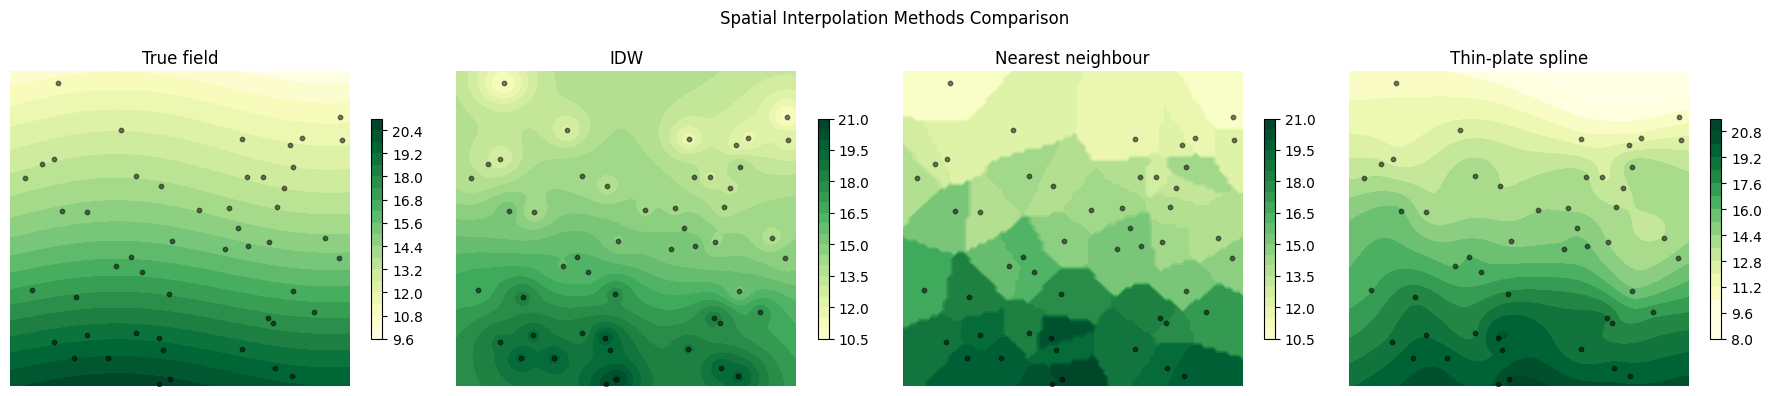

  IDW     : RMSE=1.1150
  NN      : RMSE=0.7265
  RBF/TPS : RMSE=0.6181


In [2]:
def idw(x_obs, y_obs, z_obs, gx_flat, gy_flat, power=2):
    z_pred = np.zeros(len(gx_flat))
    for i, (px, py) in enumerate(zip(gx_flat, gy_flat)):
        dists = np.sqrt((x_obs-px)**2 + (y_obs-py)**2)
        dists = np.maximum(dists, 0.1)
        w = 1 / dists**power
        z_pred[i] = (w * z_obs).sum() / w.sum()
    return z_pred

gx_flat = GX.ravel(); gy_flat = GY.ravel()
z_idw   = idw(x_obs, y_obs, z_obs, gx_flat, gy_flat).reshape(GX.shape)

# Nearest-neighbour interpolation
nn_interp = NearestNDInterpolator(np.column_stack([x_obs, y_obs]), z_obs)
z_nn = nn_interp(GX, GY)

# Thin-plate spline via RBF
rbf = RBFInterpolator(np.column_stack([x_obs, y_obs]), z_obs,
                       kernel='thin_plate_spline', smoothing=0.1)
z_rbf = rbf(np.column_stack([GX.ravel(), GY.ravel()])).reshape(GX.shape)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, Z, title in [(axes[0], z_true, 'True field'),
                      (axes[1], z_idw,  'IDW'),
                      (axes[2], z_nn,   'Nearest neighbour'),
                      (axes[3], z_rbf,  'Thin-plate spline')]:
    vmin, vmax = z_true.min(), z_true.max()
    im = ax.contourf(GX, GY, Z, levels=20, cmap='YlGn', vmin=vmin, vmax=vmax)
    ax.scatter(x_obs, y_obs, c='black', s=10, zorder=2, alpha=0.5)
    plt.colorbar(im, ax=ax, shrink=0.7)
    ax.set_title(title); ax.axis('off')
plt.suptitle('Spatial Interpolation Methods Comparison')
plt.tight_layout(); plt.show()
for name, Z in [('IDW',z_idw),('NN',z_nn),('RBF/TPS',z_rbf)]:
    rmse = np.sqrt(((Z-z_true)**2).mean())
    print(f"  {name:8s}: RMSE={rmse:.4f}")

---
## Ordinary Kriging

Variogram: nugget=2.000, psill=2.000, range=1738m


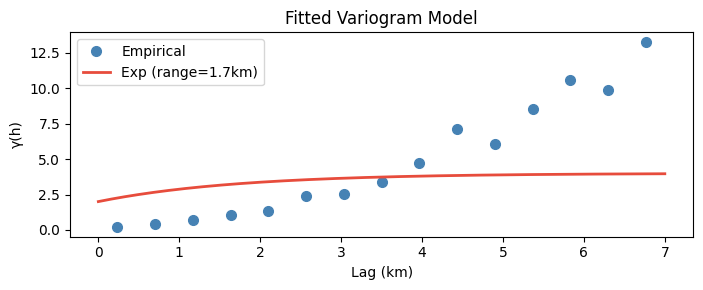

In [3]:
# Ordinary kriging: fit variogram then solve kriging system
# Step 1: empirical semivariogram
coords_obs = np.column_stack([x_obs, y_obs])
D_obs = cdist(coords_obs, coords_obs)
pairs_h, pairs_gamma = [], []
n_bins, max_dist = 15, 7000
bins = np.linspace(0, max_dist, n_bins+1)
for lo, hi in zip(bins[:-1], bins[1:]):
    mask = (D_obs > lo) & (D_obs <= hi)
    ij = list(zip(*np.where(mask & np.triu(np.ones_like(D_obs, dtype=bool), 1))))
    if ij:
        pairs_h.append((lo+hi)/2)
        pairs_gamma.append(np.mean([(z_obs[i]-z_obs[j])**2 for i,j in ij]) / 2)
h_emp  = np.array(pairs_h)
gam_emp = np.array(pairs_gamma)

# Step 2: fit exponential variogram model
def exp_vario(h, nugget, psill, a):
    return nugget + psill * (1 - np.exp(-h/a))
try:
    popt, _ = curve_fit(exp_vario, h_emp, gam_emp,
                         p0=[0.1, 0.5, 2000], bounds=([0,0,100],[2,2,10000]))
    nugget, psill, a = popt
except Exception:
    nugget, psill, a = 0.1, 0.5, 2500
print(f"Variogram: nugget={nugget:.3f}, psill={psill:.3f}, range={a:.0f}m")

fig, ax = plt.subplots(figsize=(7,3))
ax.plot(h_emp/1000, gam_emp, 'o', color='steelblue', ms=7, label='Empirical')
h_fit  = np.linspace(0, max_dist, 300)
ax.plot(h_fit/1000, exp_vario(h_fit, nugget, psill, a), '-',
        color='#e74c3c', lw=2, label=f'Exp (range={a/1000:.1f}km)')
ax.set_xlabel('Lag (km)'); ax.set_ylabel('γ(h)'); ax.legend()
ax.set_title('Fitted Variogram Model'); plt.tight_layout(); plt.show()

---
## Kriging Prediction and Variance

Kriging RMSE: 0.9188


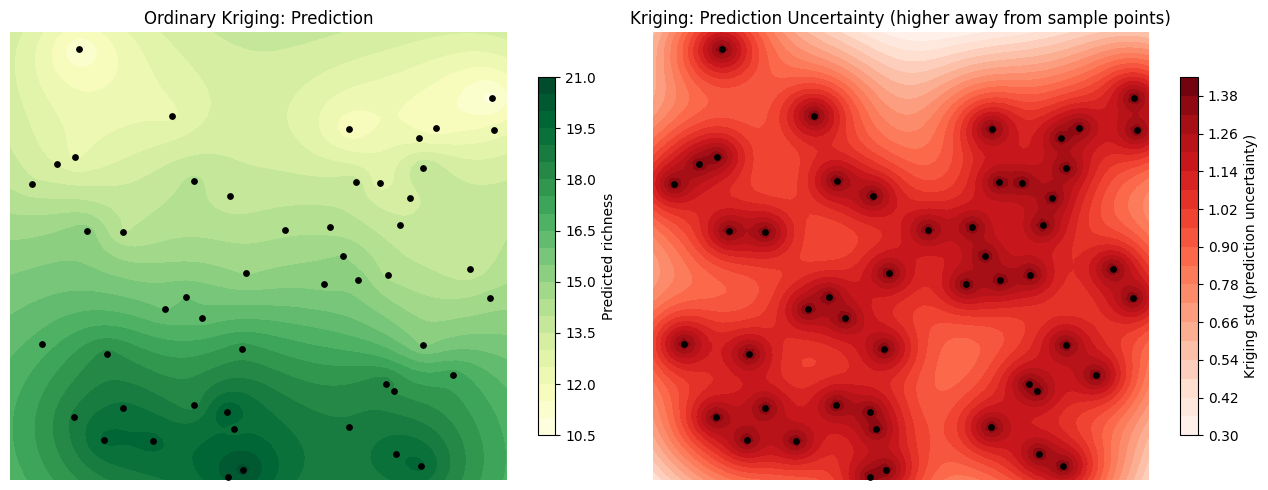

In [8]:
def ordinary_kriging_predict(x_pred, y_pred, x_obs, y_obs, z_obs,
                               nugget, psill, a, batch_size=200):
    n     = len(x_obs)
    coords_obs = np.column_stack([x_obs, y_obs])
    D_obs = cdist(coords_obs, coords_obs)
    # Kriging matrix C (n+1 x n+1 with Lagrange row/col)
    C = exp_vario(D_obs, nugget, psill, a)
    C_aug = np.block([[C, np.ones((n,1))],[np.ones((1,n)), np.zeros((1,1))]])
    z_pred_all, var_pred_all = [], []
    pred_coords = np.column_stack([x_pred, y_pred])
    for start in range(0, len(x_pred), batch_size):
        chunk = pred_coords[start:start+batch_size]
        D_op  = cdist(chunk, coords_obs)
        c0    = exp_vario(D_op, nugget, psill, a)
        c0_aug = np.hstack([c0, np.ones((len(chunk),1))])
        try:
            weights = np.linalg.solve(C_aug, c0_aug.T).T
            z_chunk   = (weights[:,:-1] * z_obs).sum(axis=1)
            var_chunk = (nugget + psill) - (weights * c0_aug).sum(axis=1)
            var_chunk = np.maximum(var_chunk, 0)
        except np.linalg.LinAlgError:
            z_chunk   = np.full(len(chunk), z_obs.mean())
            var_chunk = np.full(len(chunk), psill)
        z_pred_all.append(z_chunk); var_pred_all.append(var_chunk)
    return np.concatenate(z_pred_all), np.concatenate(var_pred_all)

z_krig, var_krig = ordinary_kriging_predict(
    gx_flat, gy_flat, x_obs, y_obs, z_obs, nugget, psill, a)
Z_krig = z_krig.reshape(GX.shape)
Z_var  = var_krig.reshape(GX.shape)
Z_std  = np.sqrt(np.maximum(Z_var, 0))
rmse_k = np.sqrt(((Z_krig.ravel() - z_true.ravel())**2).mean())
print(f"Kriging RMSE: {rmse_k:.4f}")
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
im0 = axes[0].contourf(GX, GY, Z_krig, levels=20, cmap='YlGn')
axes[0].scatter(x_obs, y_obs, c='black', s=15, zorder=2); axes[0].axis('off')
plt.colorbar(im0, ax=axes[0], label='Predicted richness', shrink=0.8)
axes[0].set_title('Ordinary Kriging: Prediction')
im1 = axes[1].contourf(GX, GY, Z_std, levels=20, cmap='Reds')
axes[1].scatter(x_obs, y_obs, c='black', s=15, zorder=2); axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], label='Kriging std (prediction uncertainty)', shrink=0.8)
axes[1].set_title('Kriging: Prediction Uncertainty (higher away from sample points)')
plt.tight_layout(); plt.show()

LOO cross-validation (n=30):
  ME (mean error, bias):  0.0221
  RMSE:                   0.7921
  MAE:                    0.6125


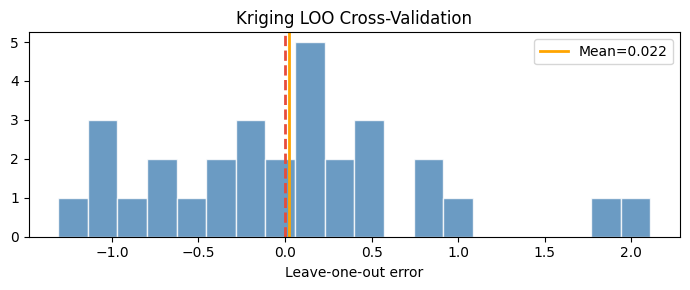

In [9]:
# Cross-validation: leave-one-out kriging
loo_errors = []
for i in range(min(30, n_obs)):   # LOO on first 30 for speed
    mask = np.ones(n_obs, dtype=bool); mask[i] = False
    x_tr, y_tr, z_tr = x_obs[mask], y_obs[mask], z_obs[mask]
    z_pred_i, _ = ordinary_kriging_predict(
        x_obs[i:i+1], y_obs[i:i+1], x_tr, y_tr, z_tr, nugget, psill, a)
    loo_errors.append(z_pred_i[0] - z_obs[i])
loo_errors = np.array(loo_errors)
print(f"LOO cross-validation (n=30):")
print(f"  ME (mean error, bias):  {loo_errors.mean():.4f}")
print(f"  RMSE:                   {np.sqrt((loo_errors**2).mean()):.4f}")
print(f"  MAE:                    {np.abs(loo_errors).mean():.4f}")
fig, ax = plt.subplots(figsize=(7,3))
ax.hist(loo_errors, bins=20, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(0, color='#e74c3c', lw=2, linestyle='--')
ax.axvline(loo_errors.mean(), color='orange', lw=2, label=f'Mean={loo_errors.mean():.3f}')
ax.set_xlabel('Leave-one-out error'); ax.set_title('Kriging LOO Cross-Validation')
ax.legend(); plt.tight_layout(); plt.show()

---

## Common Pitfalls

**1. Using IDW without considering the choice of power parameter**  
IDW with power=1 produces smoother surfaces with more influence from distant points; power=3 makes the surface nearly piecewise constant, dominated by nearby points. The power is a key tuning parameter — always cross-validate to select it, rather than defaulting to power=2.

**2. Applying kriging without fitting a valid variogram model**  
Kriging requires a positive-definite covariance function. Fitting a variogram model by eye or using empirical values directly without a valid parametric model (exponential, spherical, Gaussian) can produce a non-positive-definite kriging matrix that fails to solve or gives negative prediction variances. Always use a recognised valid model family.

**3. Reporting kriging predictions without prediction uncertainty**  
Kriging's main advantage over IDW is that it provides prediction variance alongside the interpolated value. Reporting only the predicted surface wastes this information. Always plot or tabulate kriging standard deviation alongside predictions — it shows where predictions are reliable vs uncertain.

**4. Not cross-validating interpolation results**  
A smooth-looking interpolated surface is not evidence of accuracy. Always hold out some sample points (or use LOO cross-validation) to estimate actual prediction error. Mean error (ME) detects systematic bias; RMSE measures overall accuracy.

**5. Extrapolating interpolated surfaces far beyond the sample extent**  
All interpolation methods are unreliable outside the convex hull of the sample points. IDW converges to the global mean; kriging variance increases to the sill. Always mask predictions to the extent of the sample data and clearly communicate that predictions beyond sample coverage are extrapolations with high uncertainty.

---
*python_methods_library - Samantha McGarrigle*